<a href="https://colab.research.google.com/github/JaredOzarzak/biomechanics-analysis-pipeline/blob/main/Biomechanical_Identification_of_Future_High_Velocity_Pitchers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Five-Year Velocity Projection: 2025 FCL Pitchers

The main question for this project is pretty simple: which 2025 FCL pitcher looks most likely to throw the hardest fastball five years from now?

The tricky part is that the 2025 FCL file gives us biomechanics, but it does not actually give us measured velocity. So instead of just ranking pitchers by current velo, I had to build a model using the training dataset, which includes both velocity and mechanics. From there, I used that model to estimate velocity for the 2025 FCL pitchers.

I tried to be realistic with this because velocity is not something biomechanics can explain perfectly. A lot of important stuff is missing from the data, like strength, age, health, training history, intent, and probably some physical projection. So I am not treating this like the model can perfectly predict the future. I am using it more as a way to find the best candidate and the strongest tier of arms.

The final answer comes from a mix of things: model-projected velocity, pitch count reliability, ranking stability, and the mechanical profile behind the prediction. Pitch count matters because a pitcher with 200 fastballs is a lot easier to trust than a pitcher with only 10 or 15.

## Tools Used

Python, pandas, NumPy, Matplotlib, scikit-learn, and XGBoost.

## What I am looking for

I am looking for which biomechanical traits seem most connected to fastball velocity, then using those patterns to project the 2025 FCL pitchers. The biggest areas I focused on were trunk and pelvis rotation, center-of-mass speed, throwing-arm speed, elbow extension speed, and release posture.

In [ ]:
DATA_DIR = "."  # folder holding the CSVs. In Colab with files in /content, "." works; otherwise set the path.

# ============================================================
# Environment Setup and Data Loading
# ============================================================

# Core data tools
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Optional nonlinear model
try:
    from xgboost import XGBRegressor
    xgboost_available = True
except ImportError:
    xgboost_available = False

# General notebook settings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# ------------------------------------------------------------
# Load provided datasets
# ------------------------------------------------------------

df_train = pd.read_csv(f"{DATA_DIR}/velo_and_mechanics.csv")
df_fcl_all = pd.read_csv(f"{DATA_DIR}/fcl_mechanics_2025.csv")
df_metrics = pd.read_csv(f"{DATA_DIR}/metric_descriptions.csv")

# ------------------------------------------------------------
# Date audit and primary FCL filtering decision
# ------------------------------------------------------------
# The provided FCL file contains rows from more than one year.
# Because the prompt asks which pitcher in the 2025 FCL dataset projects best,
# the primary prediction analysis uses 2025 rows only.
# The original unfiltered file is kept as df_fcl_all for audit purposes.

df_fcl_all["date"] = pd.to_datetime(df_fcl_all["date"], errors="coerce")
df_fcl = df_fcl_all[df_fcl_all["date"].dt.year == 2025].copy()

print("Datasets loaded successfully.")
print(f"Training dataset: {df_train.shape[0]:,} rows x {df_train.shape[1]} columns")
print(f"Raw FCL file: {df_fcl_all.shape[0]:,} rows x {df_fcl_all.shape[1]} columns")
print(f"2025 FCL prediction dataset after date filter: {df_fcl.shape[0]:,} rows x {df_fcl.shape[1]} columns")
print(f"Metric descriptions: {df_metrics.shape[0]:,} rows x {df_metrics.shape[1]} columns")
print(f"XGBoost available: {xgboost_available}")

Datasets loaded successfully.
Training dataset: 8,981 rows x 67 columns
Raw FCL file: 6,893 rows x 66 columns
2025 FCL prediction dataset after date filter: 5,450 rows x 66 columns
Metric descriptions: 67 rows x 3 columns
XGBoost available: True


## Initial Dataset Audit

Before building the model, I wanted to make sure the data actually matched the problem.

The training file has measured velocity, which is what the model learns from. The 2025 FCL file has the biomechanics, but not velocity, which is why we need the model in the first place.

I also checked pitcher IDs, dates, missing values, and which columns overlap between the two datasets. This matters because I do not want the model using things like pitcher ID or date as shortcuts. Those are useful for organizing the data, but they should not be treated like real biomechanical predictors.

In [ ]:
# ============================================================
# Initial Dataset Audit
# ============================================================

# ------------------------------------------------------------
# Basic dataset structure
# ------------------------------------------------------------

print("Training Dataset: velo_and_mechanics.csv")
print(f"Rows: {df_train.shape[0]:,}")
print(f"Columns: {df_train.shape[1]:,}")
print(f"Unique pitchers: {df_train['pitcher_id'].nunique():,}")
print()

print("Raw FCL File: fcl_mechanics_2025.csv")
print(f"Rows before date filter: {df_fcl_all.shape[0]:,}")
print(f"Columns: {df_fcl_all.shape[1]:,}")
print(f"Unique pitchers before date filter: {df_fcl_all['pitcher_id'].nunique():,}")
print()

print("Primary 2025 FCL Prediction Dataset")
print(f"Rows after filtering to 2025: {df_fcl.shape[0]:,}")
print(f"Columns: {df_fcl.shape[1]:,}")
print(f"Unique pitchers after filtering to 2025: {df_fcl['pitcher_id'].nunique():,}")
print()

print("Metric Descriptions")
print(f"Rows: {df_metrics.shape[0]:,}")
print(f"Columns: {df_metrics.shape[1]:,}")
print()

# ------------------------------------------------------------
# Confirm target variable setup
# ------------------------------------------------------------

train_only_columns = sorted(set(df_train.columns) - set(df_fcl.columns))
fcl_only_columns = sorted(set(df_fcl.columns) - set(df_train.columns))

print("Columns present in training data but not 2025 FCL prediction data:")
print(train_only_columns)
print()

print("Columns present in 2025 FCL prediction data but not training data:")
print(fcl_only_columns)
print()

# ------------------------------------------------------------
# Check whether pitcher IDs overlap across datasets
# ------------------------------------------------------------

train_pitchers = set(df_train["pitcher_id"].unique())
fcl_pitchers = set(df_fcl["pitcher_id"].unique())

overlapping_pitchers = train_pitchers.intersection(fcl_pitchers)

print(f"Overlapping pitcher IDs between training and 2025 FCL datasets: {len(overlapping_pitchers)}")
print()

# ------------------------------------------------------------
# Missing data summary
# ------------------------------------------------------------

train_missing = df_train.isna().sum()
train_missing = train_missing[train_missing > 0].sort_values(ascending=False)

fcl_missing = df_fcl.isna().sum()
fcl_missing = fcl_missing[fcl_missing > 0].sort_values(ascending=False)

print("Missing values in training dataset:")
display(train_missing.to_frame("missing_count"))

print("Missing values in 2025 FCL prediction dataset:")
display(fcl_missing.to_frame("missing_count"))

Training Dataset: velo_and_mechanics.csv
Rows: 8,981
Columns: 67
Unique pitchers: 203

Raw FCL File: fcl_mechanics_2025.csv
Rows before date filter: 6,893
Columns: 66
Unique pitchers before date filter: 71

Primary 2025 FCL Prediction Dataset
Rows after filtering to 2025: 5,450
Columns: 66
Unique pitchers after filtering to 2025: 71

Metric Descriptions
Rows: 67
Columns: 3

Columns present in training data but not 2025 FCL prediction data:
['velocity']

Columns present in 2025 FCL prediction data but not training data:
[]

Overlapping pitcher IDs between training and 2025 FCL datasets: 0

Missing values in training dataset:


,missing_count
glove_shoulder_abduction_at_ball_release,47
glove_shoulder_horizontal_abduction_at_ball_release,47
glove_shoulder_external_rotation_at_ball_release,47


Missing values in 2025 FCL prediction dataset:


,missing_count
glove_shoulder_abduction_at_ball_release,89
glove_shoulder_horizontal_abduction_at_ball_release,89
glove_shoulder_external_rotation_at_ball_release,89


In [ ]:
# ============================================================
# Date Audit: Confirm Years Included in FCL Prediction File
# ============================================================

print("Rows by year in raw FCL file:")
fcl_year_counts = (
    df_fcl_all["date"]
    .dt.year
    .value_counts()
    .sort_index()
    .to_frame("row_count")
)
display(fcl_year_counts)

print("Unique pitchers by year in raw FCL file:")
fcl_pitchers_by_year = (
    df_fcl_all
    .groupby(df_fcl_all["date"].dt.year)["pitcher_id"]
    .nunique()
    .to_frame("unique_pitchers")
)
display(fcl_pitchers_by_year)

print("Pitcher 119 rows by year:")
pitcher_119_year_counts = (
    df_fcl_all[df_fcl_all["pitcher_id"] == 119]["date"]
    .dt.year
    .value_counts()
    .sort_index()
    .to_frame("row_count")
)
display(pitcher_119_year_counts)

print("Primary modeling decision:")
print("The main FCL prediction analysis uses 2025 rows only.")

Rows by year in raw FCL file:


,row_count
date,
2024,1443
2025,5450


Unique pitchers by year in raw FCL file:


,unique_pitchers
date,
2024,16
2025,71


Pitcher 119 rows by year:


,row_count
date,
2024,60
2025,212


Primary modeling decision:
The main FCL prediction analysis uses 2025 rows only.


## Date Audit Takeaways

Even though the FCL file is labeled as the 2025 dataset, it also has some 2024 rows in it. For the main analysis, I filtered it down to only 2025 rows because the prompt is asking about the 2025 FCL group.

I still kept the full file available for checking trends and context, but the main rankings and final recommendation are based on the 2025 data only.

This is also why Pitcher 119 has 212 fastballs in the final analysis instead of the larger total from the raw file.

Training Velocity Summary


,velocity
count,8981.000000
mean,92.454183
std,2.679408
min,68.955808
1%,85.620477
5%,88.153084
10%,89.110535
25%,90.732372
50%,92.470448
75%,94.302472


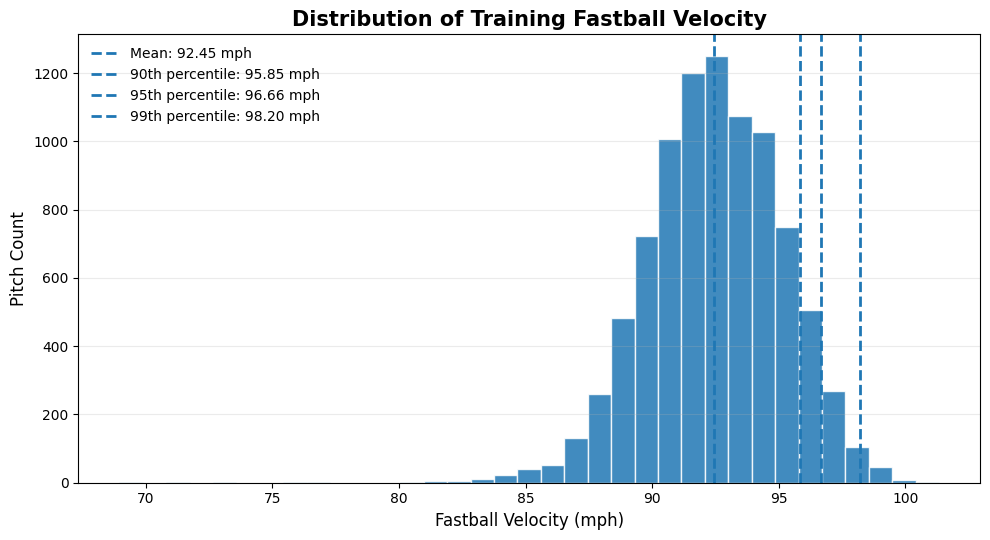

High-Velocity Thresholds
Mean velocity: 92.45 mph
Median velocity: 92.47 mph
90th percentile velocity: 95.85 mph
95th percentile velocity: 96.66 mph
99th percentile velocity: 98.20 mph


In [ ]:
# ============================================================
# Training Velocity Distribution
# ============================================================

# ------------------------------------------------------------
# Summary statistics for fastball velocity
# ------------------------------------------------------------

velocity_summary = df_train["velocity"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

print("Training Velocity Summary")
display(velocity_summary.to_frame())

# ------------------------------------------------------------
# Key velocity thresholds
# ------------------------------------------------------------

velo_mean = df_train["velocity"].mean()
velo_median = df_train["velocity"].median()
velo_90th = df_train["velocity"].quantile(0.90)
velo_95th = df_train["velocity"].quantile(0.95)
velo_99th = df_train["velocity"].quantile(0.99)

# ------------------------------------------------------------
# Clean velocity distribution plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.5))

plt.hist(
    df_train["velocity"],
    bins=35,
    alpha=0.85,
    edgecolor="white"
)

plt.axvline(velo_mean, linestyle="--", linewidth=2, label=f"Mean: {velo_mean:.2f} mph")
plt.axvline(velo_90th, linestyle="--", linewidth=2, label=f"90th percentile: {velo_90th:.2f} mph")
plt.axvline(velo_95th, linestyle="--", linewidth=2, label=f"95th percentile: {velo_95th:.2f} mph")
plt.axvline(velo_99th, linestyle="--", linewidth=2, label=f"99th percentile: {velo_99th:.2f} mph")

plt.title("Distribution of Training Fastball Velocity", fontsize=15, fontweight="bold")
plt.xlabel("Fastball Velocity (mph)", fontsize=12)
plt.ylabel("Pitch Count", fontsize=12)

plt.legend(frameon=False)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print high-velocity thresholds
# ------------------------------------------------------------

print("High-Velocity Thresholds")
print(f"Mean velocity: {velo_mean:.2f} mph")
print(f"Median velocity: {velo_median:.2f} mph")
print(f"90th percentile velocity: {velo_90th:.2f} mph")
print(f"95th percentile velocity: {velo_95th:.2f} mph")
print(f"99th percentile velocity: {velo_99th:.2f} mph")

## Velocity Distribution Takeaways

The training velocities are mostly grouped in the low 90s, with most fastballs sitting somewhere around 89 to 96 mph.

For this project, the upper end of the distribution matters the most because I am trying to find future high-velocity arms. The 90th, 95th, and 99th percentile lines help show what counts as above average, high-end, and elite within this specific dataset.

In [ ]:
# ============================================================
# Metric Dictionary Review and Biomechanical Grouping
# ============================================================

# ------------------------------------------------------------
# Display the metric description file
# ------------------------------------------------------------

print("Metric Description Preview")
display(df_metrics.head(20))

print(f"Total documented metrics: {df_metrics.shape[0]}")

# ------------------------------------------------------------
# Group columns by pitching event / timing
# ------------------------------------------------------------

foot_plant_cols = [col for col in df_train.columns if "at_foot_plant" in col]
mer_cols = [col for col in df_train.columns if "at_mer" in col]
ball_release_cols = [col for col in df_train.columns if "at_ball_release" in col]
max_velocity_cols = [col for col in df_train.columns if "velo_max" in col]

# ------------------------------------------------------------
# Group columns by biomechanical region
# ------------------------------------------------------------

lower_body_cols = [
    col for col in df_train.columns
    if any(term in col for term in ["hip", "knee", "leg", "stride", "center_of_mass"])
]

trunk_pelvis_cols = [
    col for col in df_train.columns
    if any(term in col for term in ["pelvis", "torso", "hip_shoulder"])
]

throwing_arm_cols = [
    col for col in df_train.columns
    if col.startswith("throw_") or col == "arm_slot"
]

glove_arm_cols = [
    col for col in df_train.columns
    if col.startswith("glove_")
]

metadata_cols = ["date", "pitcher_id", "pitcher_handedness"]
target_col = ["velocity"]
physical_cols = ["player_height"]

# ------------------------------------------------------------
# Summarize biomechanical groups
# ------------------------------------------------------------

group_summary = pd.DataFrame({
    "Group": [
        "Foot Plant Metrics",
        "MER Metrics",
        "Ball Release Metrics",
        "Maximum Velocity Metrics",
        "Lower Body Metrics",
        "Trunk / Pelvis Metrics",
        "Throwing Arm Metrics",
        "Glove Arm Metrics",
        "Physical Metrics",
        "Metadata Columns",
        "Target Variable"
    ],
    "Number of Columns": [
        len(foot_plant_cols),
        len(mer_cols),
        len(ball_release_cols),
        len(max_velocity_cols),
        len(lower_body_cols),
        len(trunk_pelvis_cols),
        len(throwing_arm_cols),
        len(glove_arm_cols),
        len(physical_cols),
        len(metadata_cols),
        len(target_col)
    ]
})

display(group_summary)

# ------------------------------------------------------------
# Show examples from each important group
# ------------------------------------------------------------

print("Example Foot Plant Metrics:")
print(foot_plant_cols[:8])
print()

print("Example MER Metrics:")
print(mer_cols[:8])
print()

print("Example Ball Release Metrics:")
print(ball_release_cols[:8])
print()

print("Example Maximum Velocity Metrics:")
print(max_velocity_cols)
print()

print("Example Trunk / Pelvis Metrics:")
print(trunk_pelvis_cols[:10])

Metric Description Preview


,Column,Description,Units
0,date,The date on which the pitch was thrown,NaN
1,pitcher_id,A unique identifier for the pitcher,NaN
2,pitcher_handedness,The handedness (l or r) of the pitcher,NaN
3,velocity,The pitch's velocity,mph
4,player_height,The player's height,ft
5,arm_slot,The pitcher's arm slot on the pitch,deg
6,back_hip_flexion_at_foot_plant,The flexion angle of the pitcher's back hip at...,deg
7,back_hip_flexion_at_mer,The flexion angle of the pitcher's back hip at...,deg
8,back_hip_flexion_at_ball_release,The flexion angle of the pitcher's back hip at...,deg
9,back_knee_flexion_at_foot_plant,The flexion angle of the pitcher's back knee a...,deg


Total documented metrics: 67


,Group,Number of Columns
0,Foot Plant Metrics,17
1,MER Metrics,15
2,Ball Release Metrics,17
3,Maximum Velocity Metrics,8
4,Lower Body Metrics,21
5,Trunk / Pelvis Metrics,17
6,Throwing Arm Metrics,15
7,Glove Arm Metrics,12
8,Physical Metrics,1
9,Metadata Columns,3


Example Foot Plant Metrics:
['back_hip_flexion_at_foot_plant', 'back_knee_flexion_at_foot_plant', 'glove_elbow_flexion_at_foot_plant', 'glove_shoulder_abduction_at_foot_plant', 'glove_shoulder_horizontal_abduction_at_foot_plant', 'glove_shoulder_external_rotation_at_foot_plant', 'hip_shoulder_separation_at_foot_plant', 'lead_hip_flexion_at_foot_plant']

Example MER Metrics:
['back_hip_flexion_at_mer', 'back_knee_flexion_at_mer', 'glove_elbow_flexion_at_mer', 'glove_shoulder_abduction_at_mer', 'glove_shoulder_horizontal_abduction_at_mer', 'glove_shoulder_external_rotation_at_mer', 'lead_hip_flexion_at_mer', 'lead_knee_flexion_at_mer']

Example Ball Release Metrics:
['back_hip_flexion_at_ball_release', 'back_knee_flexion_at_ball_release', 'glove_elbow_flexion_at_ball_release', 'glove_shoulder_abduction_at_ball_release', 'glove_shoulder_horizontal_abduction_at_ball_release', 'glove_shoulder_external_rotation_at_ball_release', 'hip_shoulder_separation_at_ball_release', 'lead_hip_flexion_at

## Biomechanical Correlation Analysis

Next, I looked at which biomechanical variables had the strongest relationship with fastball velocity.

This is not the final model by itself, but it is a good first step. It helps show which mechanics are actually moving with velocity in this dataset instead of just guessing based on what usually sounds important.

I am also not treating correlation like proof. Pitching is too complex for that. A single variable can look important on its own, but velocity usually comes from how multiple parts of the delivery work together.

Top Positive Correlations with Velocity


,correlation
torso_sidebend_at_mer,0.320557
torso_rotation_velo_max,0.288139
torso_sidebend_at_ball_release,0.282946
arm_slot,0.240497
throw_elbow_extension_velo_max,0.204184
torso_forward_bend_at_ball_release,0.180116
center_of_mass_velo_max,0.177934
glove_shoulder_abduction_at_mer,0.174926
glove_shoulder_abduction_at_ball_release,0.162091
glove_elbow_flexion_at_foot_plant,0.154563


Top Negative Correlations with Velocity


,correlation
pelvis_rotation_at_foot_plant,-0.035557
back_hip_flexion_at_ball_release,-0.043670
torso_rotation_at_foot_plant,-0.052097
glove_shoulder_abduction_at_foot_plant,-0.053865
back_knee_flexion_at_mer,-0.060447
back_hip_flexion_at_foot_plant,-0.064934
back_knee_flexion_at_ball_release,-0.069257
back_hip_flexion_at_mer,-0.077080
lead_leg_internal_rotation_velo_max,-0.084681
throw_elbow_flexion_at_ball_release,-0.112895


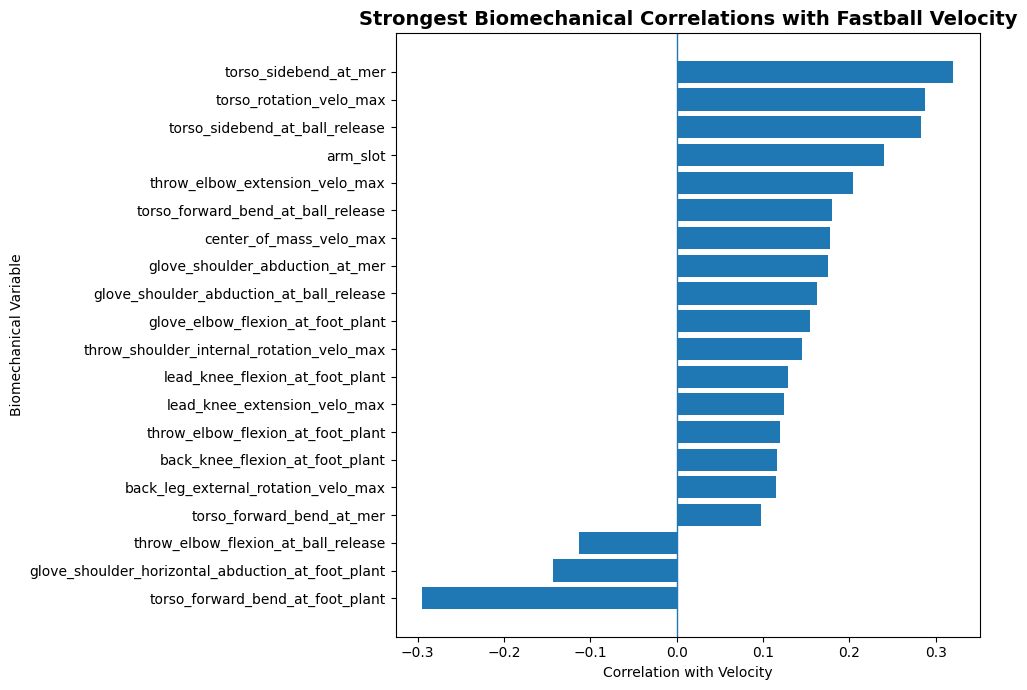

In [ ]:
# ============================================================
# Biomechanical Correlation Analysis
# ============================================================

# ------------------------------------------------------------
# Select numeric columns only
# ------------------------------------------------------------

numeric_df = df_train.select_dtypes(include=[np.number]).copy()

# Remove pitcher_id from correlation analysis because it is an identifier
if "pitcher_id" in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=["pitcher_id"])

# ------------------------------------------------------------
# Calculate correlation with velocity
# ------------------------------------------------------------

velocity_corr = numeric_df.corr()["velocity"].drop("velocity").sort_values(ascending=False)

# Most positive and negative relationships
top_positive_corr = velocity_corr.head(12)
top_negative_corr = velocity_corr.tail(12)

print("Top Positive Correlations with Velocity")
display(top_positive_corr.to_frame("correlation"))

print("Top Negative Correlations with Velocity")
display(top_negative_corr.to_frame("correlation"))

# ------------------------------------------------------------
# Combine strongest absolute correlations for visualization
# ------------------------------------------------------------

top_abs_corr = velocity_corr.abs().sort_values(ascending=False).head(20)
top_abs_corr_values = velocity_corr.loc[top_abs_corr.index].sort_values()

# ------------------------------------------------------------
# Plot strongest velocity relationships
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))
plt.barh(top_abs_corr_values.index, top_abs_corr_values.values)

plt.axvline(0, linewidth=1)
plt.title("Strongest Biomechanical Correlations with Fastball Velocity", fontsize=14, fontweight="bold")
plt.xlabel("Correlation with Velocity")
plt.ylabel("Biomechanical Variable")

plt.tight_layout()
plt.show()

## High-Velocity Pitch Profile

To make the results easier to understand, I compared the hardest pitches in the training dataset against the rest of the sample.

I labeled pitches in the top 10 percent of velocity as the high-velocity group. Then I looked at what mechanical traits separated that group from everyone else.

This gives a better idea of what the higher-velocity profile looks like before applying the model to the 2025 FCL pitchers.

High-velocity threshold: 95.85 mph
velocity_group
Remaining 90%       8082
Top 10% Velocity     899
Name: count, dtype: int64

Largest biomechanical differences between high-velocity pitches and the rest of the sample:


,Top 10% Velocity Mean,Remaining 90% Mean,Raw Difference,Standardized Difference
glove_shoulder_external_rotation_at_foot_plant,-18.309782,-30.327777,12.017995,0.549879
torso_rotation_velo_max,1143.585320,1056.731653,86.853667,0.542644
glove_shoulder_horizontal_abduction_at_foot_plant,29.698397,37.446730,-7.748333,-0.437532
glove_shoulder_abduction_at_mer,46.407198,42.543505,3.863693,0.421418
pelvis_rotation_at_mer,75.220238,78.010260,-2.790022,-0.407086
torso_sidebend_at_mer,29.358857,25.338431,4.020426,0.405030
glove_shoulder_external_rotation_at_mer,17.315533,10.828929,6.486603,0.393362
torso_forward_bend_at_foot_plant,-4.284981,-1.515198,-2.769783,-0.390284
glove_shoulder_abduction_at_ball_release,46.099894,42.519310,3.580585,0.389421
torso_sidebend_at_ball_release,28.375520,24.580091,3.795430,0.358213


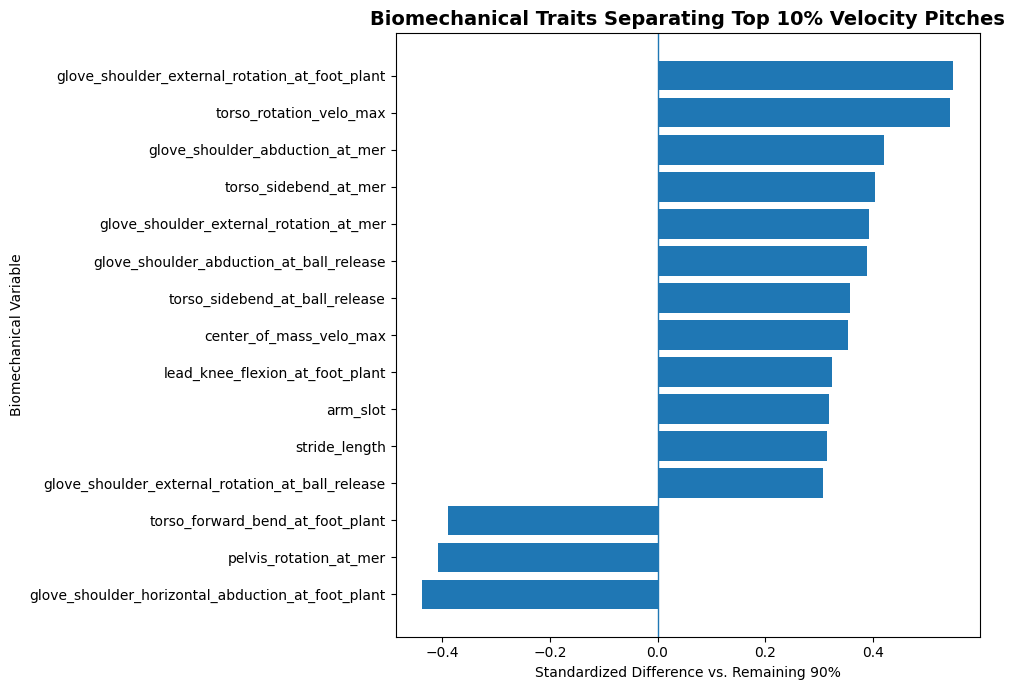

In [ ]:
# ============================================================
# High-Velocity Pitch Profile
# ============================================================

# ------------------------------------------------------------
# Define high-velocity threshold
# ------------------------------------------------------------

high_velocity_threshold = df_train["velocity"].quantile(0.90)

df_train["velocity_group"] = np.where(
    df_train["velocity"] >= high_velocity_threshold,
    "Top 10% Velocity",
    "Remaining 90%"
)

print(f"High-velocity threshold: {high_velocity_threshold:.2f} mph")
print(df_train["velocity_group"].value_counts())
print()

# ------------------------------------------------------------
# Select numeric biomechanical features
# ------------------------------------------------------------

exclude_cols = ["pitcher_id", "velocity"]

numeric_features = [
    col for col in df_train.select_dtypes(include=[np.number]).columns
    if col not in exclude_cols
]

# ------------------------------------------------------------
# Compare mean mechanics between groups
# ------------------------------------------------------------

group_means = df_train.groupby("velocity_group")[numeric_features].mean()

comparison = pd.DataFrame({
    "Top 10% Velocity Mean": group_means.loc["Top 10% Velocity"],
    "Remaining 90% Mean": group_means.loc["Remaining 90%"]
})

comparison["Raw Difference"] = (
    comparison["Top 10% Velocity Mean"] - comparison["Remaining 90% Mean"]
)

# Standardized difference makes variables with different units comparable
comparison["Standardized Difference"] = (
    comparison["Raw Difference"] / df_train[numeric_features].std()
)

comparison = comparison.sort_values(
    by="Standardized Difference",
    key=lambda x: abs(x),
    ascending=False
)

print("Largest biomechanical differences between high-velocity pitches and the rest of the sample:")
display(comparison.head(15))

# ------------------------------------------------------------
# Visualize the largest standardized differences
# ------------------------------------------------------------

top_differences = comparison.head(15).sort_values("Standardized Difference")

plt.figure(figsize=(10, 7))
plt.barh(
    top_differences.index,
    top_differences["Standardized Difference"]
)

plt.axvline(0, linewidth=1)
plt.title("Biomechanical Traits Separating Top 10% Velocity Pitches", fontsize=14, fontweight="bold")
plt.xlabel("Standardized Difference vs. Remaining 90%")
plt.ylabel("Biomechanical Variable")
plt.tight_layout()
plt.show()

## Pitcher-Level Sample Size and Reliability

The data is pitch-level, but the question is pitcher-level. Each row is one fastball, but the final answer needs to be one pitcher.

That makes pitch count important. If a pitcher only has a few fastballs, the projection can be pretty noisy. If he has a larger sample, the average projection is easier to trust.

So later in the notebook, I aggregate the pitch-level predictions into pitcher-level results. I also keep pitch count as a reliability check, not as part of the actual velocity score.

Training Pitcher-Level Summary


,pitcher_id,pitch_count,mean_velocity,max_velocity,p90_velocity,p95_velocity
116,146,20,98.590464,101.334670,99.608266,100.735512
176,229,23,97.400340,98.723895,98.310054,98.398490
38,44,21,97.184911,99.227404,98.521628,98.745734
8,11,21,97.103916,100.099247,99.377828,100.083299
151,194,62,96.731166,100.577328,99.003782,99.278664
19,23,6,96.581070,97.247080,97.015773,97.131427
167,218,196,96.535884,99.698770,98.275227,98.596207
67,78,15,96.534604,97.894425,97.455095,97.641942
21,25,71,96.141695,99.412100,98.682621,98.949936
153,201,12,96.136419,97.682461,97.176827,97.443936


FCL Pitcher-Level Pitch Counts


,pitcher_id,pitch_count
46,200,352
16,106,299
10,81,270
13,96,234
5,46,227
22,119,212
61,254,187
51,225,180
20,116,175
12,94,159


FCL Sample Reliability Groups


,Sample Reliability Group,Number of Pitchers
0,Low sample,20
1,Moderate sample,32
2,Strong sample,19


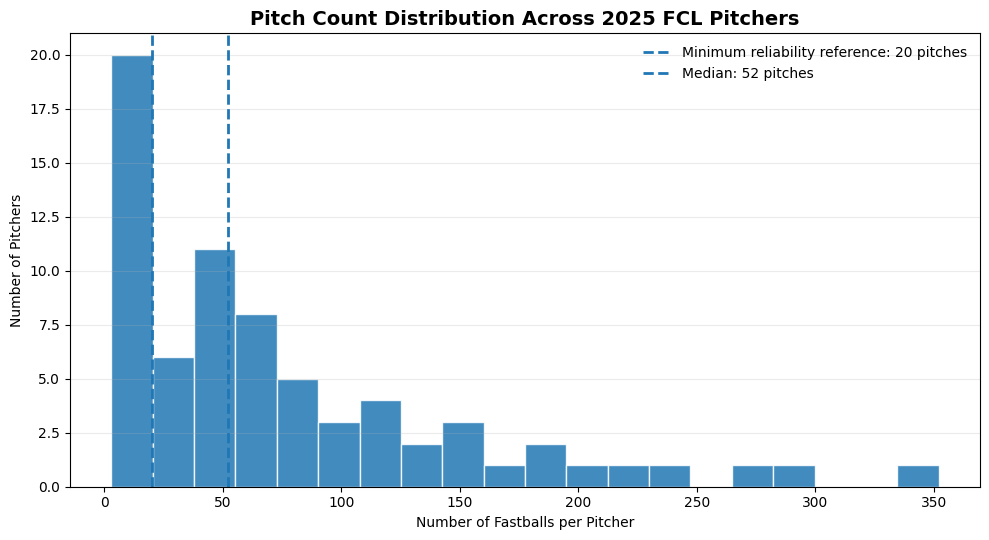

FCL Pitch Count Summary


,pitch_count
count,71.000000
mean,76.760563
std,76.174136
min,3.000000
25%,19.000000
50%,52.000000
75%,112.500000
max,352.000000


Number of FCL pitchers with fewer than 20 pitches: 20


In [ ]:
# ============================================================
# Pitcher-Level Sample Size and Reliability
# ============================================================

# ------------------------------------------------------------
# Training dataset pitcher-level summary
# ------------------------------------------------------------

train_pitcher_summary = (
    df_train
    .groupby("pitcher_id")
    .agg(
        pitch_count=("velocity", "count"),
        mean_velocity=("velocity", "mean"),
        max_velocity=("velocity", "max"),
        p90_velocity=("velocity", lambda x: x.quantile(0.90)),
        p95_velocity=("velocity", lambda x: x.quantile(0.95))
    )
    .reset_index()
    .sort_values("mean_velocity", ascending=False)
)

print("Training Pitcher-Level Summary")
display(train_pitcher_summary.head(10))

# ------------------------------------------------------------
# FCL dataset pitcher-level pitch count summary
# ------------------------------------------------------------

fcl_pitcher_summary = (
    df_fcl
    .groupby("pitcher_id")
    .size()
    .reset_index(name="pitch_count")
    .sort_values("pitch_count", ascending=False)
)

print("FCL Pitcher-Level Pitch Counts")
display(fcl_pitcher_summary.head(10))

# ------------------------------------------------------------
# Create sample reliability labels
# ------------------------------------------------------------

def assign_sample_reliability(pitch_count):
    if pitch_count < 20:
        return "Low sample"
    elif pitch_count < 100:
        return "Moderate sample"
    else:
        return "Strong sample"

fcl_pitcher_summary["sample_reliability"] = fcl_pitcher_summary["pitch_count"].apply(assign_sample_reliability)

reliability_counts = (
    fcl_pitcher_summary["sample_reliability"]
    .value_counts()
    .reindex(["Low sample", "Moderate sample", "Strong sample"])
    .reset_index()
)

reliability_counts.columns = ["Sample Reliability Group", "Number of Pitchers"]

print("FCL Sample Reliability Groups")
display(reliability_counts)

# ------------------------------------------------------------
# Clean pitch count distribution plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.5))

plt.hist(
    fcl_pitcher_summary["pitch_count"],
    bins=20,
    edgecolor="white",
    alpha=0.85
)

plt.axvline(
    20,
    linestyle="--",
    linewidth=2,
    label="Minimum reliability reference: 20 pitches"
)

plt.axvline(
    fcl_pitcher_summary["pitch_count"].median(),
    linestyle="--",
    linewidth=2,
    label=f"Median: {fcl_pitcher_summary['pitch_count'].median():.0f} pitches"
)

plt.title("Pitch Count Distribution Across 2025 FCL Pitchers", fontsize=14, fontweight="bold")
plt.xlabel("Number of Fastballs per Pitcher")
plt.ylabel("Number of Pitchers")
plt.legend(frameon=False)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print summary statistics
# ------------------------------------------------------------

print("FCL Pitch Count Summary")
display(fcl_pitcher_summary["pitch_count"].describe().to_frame())

low_sample_pitchers = fcl_pitcher_summary[fcl_pitcher_summary["pitch_count"] < 20]

print(f"Number of FCL pitchers with fewer than 20 pitches: {len(low_sample_pitchers)}")

## Pitcher-Level Sample Size Takeaways

The FCL sample is not even across pitchers. Some pitchers have a lot of fastballs, while others have fewer than 20.

That matters because a small sample can make a pitcher look better or worse than he really is. For the final ranking, I use pitch count as a filter so the answer is not based on one small stretch of pitches.

Pitchers with bigger samples are not automatically ranked higher, but their projections are easier to trust.

## Data Cleaning and Model-Ready Feature Set

Before modeling, I made sure the training data and FCL data were using the same features.

I only kept columns that existed in both datasets. I removed things like pitcher ID and date because those are identifiers, not real mechanical inputs. Velocity stayed in the training data only as the target variable.

For missing values, I filled them using the median from the training dataset. That way the same cleaning process was applied to both the training data and the FCL prediction data.

In [ ]:
# ============================================================
# Data Cleaning and Model-Ready Feature Set
# ============================================================

# ------------------------------------------------------------
# Create working copies
# ------------------------------------------------------------

train_clean = df_train.copy()
fcl_clean = df_fcl.copy()

# ------------------------------------------------------------
# Define target and non-predictive columns
# ------------------------------------------------------------

target_col = "velocity"

identifier_cols = [
    "date",
    "pitcher_id"
]

# ------------------------------------------------------------
# Use only columns shared by both datasets
# ------------------------------------------------------------

shared_columns = sorted(list(set(train_clean.columns).intersection(set(fcl_clean.columns))))

# Remove non-predictive identifier columns
feature_columns = [
    col for col in shared_columns
    if col not in identifier_cols
]

print(f"Shared columns available for modeling: {len(shared_columns)}")
print(f"Feature columns before encoding: {len(feature_columns)}")
print()

# ------------------------------------------------------------
# Build feature matrices and target vector
# ------------------------------------------------------------

X_train_raw = train_clean[feature_columns].copy()
y = train_clean[target_col].copy()

X_fcl_raw = fcl_clean[feature_columns].copy()

# ------------------------------------------------------------
# One-hot encode categorical variables, such as pitcher handedness
# ------------------------------------------------------------

X_train_encoded = pd.get_dummies(X_train_raw, drop_first=False)
X_fcl_encoded = pd.get_dummies(X_fcl_raw, drop_first=False)

# Align FCL columns to match training columns exactly
X_fcl_encoded = X_fcl_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"Feature columns after encoding: {X_train_encoded.shape[1]}")
print()

# ------------------------------------------------------------
# Median imputation using training-set medians
# ------------------------------------------------------------

training_medians = X_train_encoded.median(numeric_only=True)

X_train_model = X_train_encoded.fillna(training_medians)
X_fcl_model = X_fcl_encoded.fillna(training_medians)

# ------------------------------------------------------------
# Final checks
# ------------------------------------------------------------

print("Final Modeling Matrices")
print("-----------------------")
print(f"Training features: {X_train_model.shape[0]:,} rows x {X_train_model.shape[1]} columns")
print(f"Training target: {y.shape[0]:,} rows")
print(f"FCL features: {X_fcl_model.shape[0]:,} rows x {X_fcl_model.shape[1]} columns")
print()

print("Remaining missing values")
print("------------------------")
print(f"Training feature missing values: {X_train_model.isna().sum().sum()}")
print(f"FCL feature missing values: {X_fcl_model.isna().sum().sum()}")

# ------------------------------------------------------------
# Preview final feature matrix
# ------------------------------------------------------------

display(X_train_model.head())

Shared columns available for modeling: 66
Feature columns before encoding: 64

Feature columns after encoding: 65

Final Modeling Matrices
-----------------------
Training features: 8,981 rows x 65 columns
Training target: 8,981 rows
FCL features: 5,450 rows x 65 columns

Remaining missing values
------------------------
Training feature missing values: 0
FCL feature missing values: 0


,arm_slot,back_hip_flexion_at_ball_release,back_hip_flexion_at_foot_plant,back_hip_flexion_at_mer,back_knee_flexion_at_ball_release,back_knee_flexion_at_foot_plant,back_knee_flexion_at_mer,back_leg_external_rotation_velo_max,center_of_mass_velo_max,glove_elbow_flexion_at_ball_release,glove_elbow_flexion_at_foot_plant,glove_elbow_flexion_at_mer,glove_shoulder_abduction_at_ball_release,glove_shoulder_abduction_at_foot_plant,glove_shoulder_abduction_at_mer,glove_shoulder_external_rotation_at_ball_release,glove_shoulder_external_rotation_at_foot_plant,glove_shoulder_external_rotation_at_mer,glove_shoulder_horizontal_abduction_at_ball_release,glove_shoulder_horizontal_abduction_at_foot_plant,glove_shoulder_horizontal_abduction_at_mer,hip_shoulder_separation_at_ball_release,hip_shoulder_separation_at_foot_plant,hip_shoulder_separation_max,lead_hip_flexion_at_ball_release,lead_hip_flexion_at_foot_plant,lead_hip_flexion_at_mer,lead_knee_extension_velo_max,lead_knee_flexion_at_ball_release,lead_knee_flexion_at_foot_plant,lead_knee_flexion_at_mer,lead_leg_internal_rotation_velo_max,pelvis_rotation_at_ball_release,pelvis_rotation_at_foot_plant,pelvis_rotation_at_mer,pelvis_rotation_velo_max,player_height,stride_angle,stride_length,throw_elbow_extension_velo_max,throw_elbow_flexion_at_ball_release,throw_elbow_flexion_at_foot_plant,throw_elbow_flexion_at_mer,throw_shoulder_abduction_at_ball_release,throw_shoulder_abduction_at_foot_plant,throw_shoulder_abduction_at_mer,throw_shoulder_external_rotation_at_ball_release,throw_shoulder_external_rotation_at_foot_plant,throw_shoulder_external_rotation_max,throw_shoulder_horizontal_abduction_at_ball_release,throw_shoulder_horizontal_abduction_at_foot_plant,throw_shoulder_horizontal_abduction_at_mer,throw_shoulder_internal_rotation_velo_max,torso_forward_bend_at_ball_release,torso_forward_bend_at_foot_plant,torso_forward_bend_at_mer,torso_rotation_at_ball_release,torso_rotation_at_foot_plant,torso_rotation_at_mer,torso_rotation_velo_max,torso_sidebend_at_ball_release,torso_sidebend_at_foot_plant,torso_sidebend_at_mer,pitcher_handedness_l,pitcher_handedness_r
0,18.958979,8.609190,8.737091,0.236525,61.710914,37.153584,54.842714,403.528547,9.282,120.390589,55.776805,119.673674,47.914000,91.743000,45.033000,28.661000,-18.092,32.148000,-41.323000,14.410000,-28.113000,6.027351,33.636633,38.269404,70.098852,56.187892,72.314313,778.117132,15.049664,32.563857,29.139354,-59.594356,82.337553,27.242040,79.848737,486.341139,6.02,-3.978063,5.016754,1780.233023,42.356374,112.748743,74.217675,95.537985,92.896098,94.154153,179.207221,22.809387,193.141758,-21.042036,49.320747,-11.947681,1946.800300,33.647129,14.577113,27.436467,91.454534,-7.732481,78.113201,858.673659,16.107166,-5.739233,13.715885,False,True
1,-2.570000,4.945000,13.148000,4.539000,26.063000,26.854000,25.956000,871.500000,10.213,96.569000,88.900000,96.756000,41.292000,82.658997,41.167999,14.824000,-63.549,14.026000,-43.405998,61.409000,-42.442001,-7.381000,40.430000,41.783000,82.416000,63.563000,82.335000,358.796000,33.684000,35.267000,34.010000,-192.285000,83.253000,22.872000,83.002000,707.745000,6.10,-9.527000,5.575000,1950.481000,63.161000,103.801000,65.148000,90.146000,88.426000,90.372000,231.458000,23.215000,230.619000,-12.688000,41.718000,-12.418000,3698.317000,41.033000,11.007000,40.745000,102.220000,-16.753000,101.397000,983.591000,8.816000,9.500000,8.859000,False,True
2,1.513000,13.244000,24.538000,7.823000,33.775000,28.025000,31.434000,783.260000,10.310,98.313000,79.945000,99.684000,41.866001,84.474998,41.283001,24.228001,-61.299,17.922001,-48.481998,54.400002,-41.206001,-9.946000,42.367000,46.280000,82.703000,61.729000,82.164000,360.413000,29.489000,36.665000,34.320000,-161.501000,86.419000,15.603000,83.479000,678.978000,6.06,-9.212000,5.509000,1901.485000,31.097000,96.234000,57.150000,90.170000,88.353000,90.046000,200.394000,9.854000,212.792000,-17.939000,35.090000,-11.310000,4074.560000,46.599000,10.700000,42.961000,110.415000,-25.497000

## Model Validation Strategy

Since the goal is to predict pitchers the model has not seen before, I used grouped cross-validation by pitcher ID.

That means the same pitcher cannot show up in both the training and testing part of the same fold. This is important because otherwise the model could learn patterns from a pitcher it has already seen and make the results look better than they really are.

I used five folds instead of one train/test split because one split can be random and noisy. With grouped five-fold validation, the model gets tested across multiple unseen groups of pitchers, which gives a more honest idea of how well it performs.

In [ ]:
# ============================================================
# Pitcher-Grouped Cross-Validation Setup
# ============================================================

from sklearn.model_selection import GroupKFold, cross_val_predict

groups = df_train["pitcher_id"]
gkf = GroupKFold(n_splits=5)

print("Validation: 5-fold GroupKFold, grouped by pitcher_id")
print("-------------------------------------------------------")
print(f"Pitchers: {groups.nunique():,}")
print(f"Pitches:  {len(groups):,}")
print("Every fold trains on one set of pitchers and tests on a disjoint set,")
print("so the scores reflect generalization to arms the model has not seen.")

Validation: 5-fold GroupKFold, grouped by pitcher_id
-------------------------------------------------------
Pitchers: 203
Pitches:  8,981
Every fold trains on one set of pitchers and tests on a disjoint set,
so the scores reflect generalization to arms the model has not seen.


## Model Comparison and Selection

I compared a few different regression models to see which one handled the data best.

The main thing I cared about was how each model performed on pitchers it had not seen before. I looked at RMSE, MAE, and R2 from the grouped cross-validation results.

After that, I picked the model with the best overall validation performance and used it for the final FCL predictions.

In [ ]:
# ============================================================
# Fast Cross-Validated Model Comparison
# ============================================================

from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Baseline Mean Model": DummyRegressor(strategy="mean"),

    "Ridge Regression": make_pipeline(
        StandardScaler(),
        Ridge(alpha=10.0)
    ),

    "Small Random Forest": RandomForestRegressor(
        n_estimators=25,
        max_depth=8,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    )
}

oof_predictions = {}
metric_rows = []

for model_name, model in models.items():
    print(f"Running {model_name}...")

    oof = cross_val_predict(
        model,
        X_train_model,
        y,
        cv=gkf,
        groups=groups,
        n_jobs=1
    )

    oof_predictions[model_name] = oof

    metric_rows.append({
        "Model": model_name,
        "RMSE": np.sqrt(mean_squared_error(y, oof)),
        "MAE": mean_absolute_error(y, oof),
        "R2": r2_score(y, oof),
    })

model_comparison = (
    pd.DataFrame(metric_rows)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

print("Fast Cross-Validated Model Results")
display(model_comparison.round(3))

# Force Small Random Forest for final model interpretability and smoother downstream cells
best_model_name = "Small Random Forest"
oof_best = oof_predictions[best_model_name]

best_model = clone(models[best_model_name])
best_model.fit(X_train_model, y)

print(f"\nForced selected model for final analysis: {best_model_name}")
print(
    model_comparison[
        model_comparison["Model"] == best_model_name
    ][["RMSE", "MAE", "R2"]].round(3)
)

Running Baseline Mean Model...
Running Ridge Regression...
Running Small Random Forest...
Fast Cross-Validated Model Results


,Model,RMSE,MAE,R2
0,Small Random Forest,2.582,2.062,0.072
1,Baseline Mean Model,2.683,2.119,-0.003
2,Ridge Regression,2.774,2.107,-0.072



Forced selected model for final analysis: Small Random Forest
    RMSE    MAE     R2
0  2.582  2.062  0.072


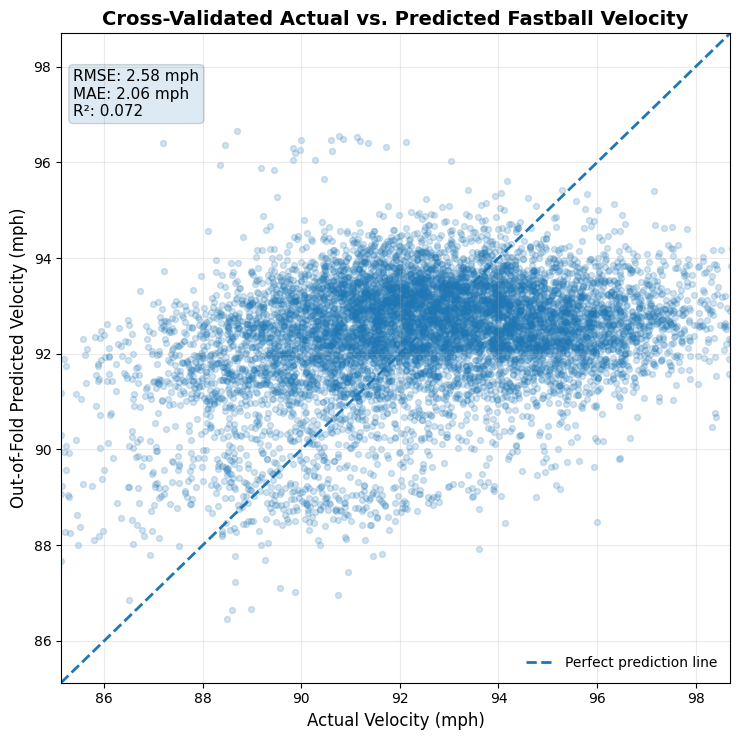

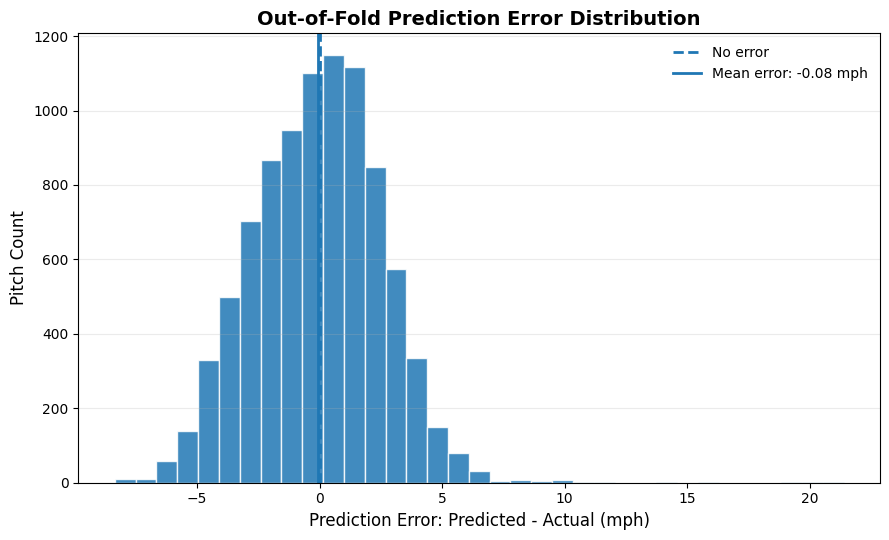

Out-of-Fold Prediction Error Summary


,prediction_error
count,8981.000000
mean,-0.077770
std,2.580520
min,-8.351246
25%,-1.903580
50%,0.007917
75%,1.696916
max,21.383127


Validation Metrics


,Metric,Value
0,RMSE,2.582
1,MAE,2.062
2,R2,0.072


In [ ]:
# ============================================================
# Validation Visualization: Cross-Validated Actual vs. Predicted
# ============================================================

validation_results = pd.DataFrame({
    "actual_velocity": y.values,
    "predicted_velocity": oof_best
})

validation_results["prediction_error"] = (
    validation_results["predicted_velocity"] - validation_results["actual_velocity"]
)

# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

val_rmse = np.sqrt(mean_squared_error(
    validation_results["actual_velocity"],
    validation_results["predicted_velocity"]
))

val_mae = mean_absolute_error(
    validation_results["actual_velocity"],
    validation_results["predicted_velocity"]
)

val_r2 = r2_score(
    validation_results["actual_velocity"],
    validation_results["predicted_velocity"]
)

# ------------------------------------------------------------
# Cleaner Actual vs. Predicted Plot
# ------------------------------------------------------------

plt.figure(figsize=(7.5, 7.5))

plt.scatter(
    validation_results["actual_velocity"],
    validation_results["predicted_velocity"],
    alpha=0.20,
    s=18
)

# Use percentile-based limits so the main cloud is easier to see
lower_limit = min(
    validation_results["actual_velocity"].quantile(0.01),
    validation_results["predicted_velocity"].quantile(0.01)
) - 0.5

upper_limit = max(
    validation_results["actual_velocity"].quantile(0.99),
    validation_results["predicted_velocity"].quantile(0.99)
) + 0.5

plt.plot(
    [lower_limit, upper_limit],
    [lower_limit, upper_limit],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction line"
)

plt.xlim(lower_limit, upper_limit)
plt.ylim(lower_limit, upper_limit)

plt.title(
    "Cross-Validated Actual vs. Predicted Fastball Velocity",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Actual Velocity (mph)", fontsize=12)
plt.ylabel("Out-of-Fold Predicted Velocity (mph)", fontsize=12)

plt.text(
    lower_limit + 0.25,
    upper_limit - 0.75,
    f"RMSE: {val_rmse:.2f} mph\nMAE: {val_mae:.2f} mph\nR²: {val_r2:.3f}",
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.grid(alpha=0.25)
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Cleaner Prediction Error Distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 5.5))

plt.hist(
    validation_results["prediction_error"],
    bins=35,
    edgecolor="white",
    alpha=0.85
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="No error"
)

plt.axvline(
    validation_results["prediction_error"].mean(),
    linestyle="-",
    linewidth=2,
    label=f"Mean error: {validation_results['prediction_error'].mean():.2f} mph"
)

plt.title(
    "Out-of-Fold Prediction Error Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Prediction Error: Predicted - Actual (mph)", fontsize=12)
plt.ylabel("Pitch Count", fontsize=12)

plt.grid(axis="y", alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print summary table
# ------------------------------------------------------------

print("Out-of-Fold Prediction Error Summary")
display(validation_results["prediction_error"].describe().to_frame())

print("Validation Metrics")
display(pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R2"],
    "Value": [val_rmse, val_mae, val_r2]
}).round(3))

Top 20 Model Feature Importances


,feature,importance
62,torso_sidebend_at_mer,0.184265
59,torso_rotation_velo_max,0.142042
36,player_height,0.052499
16,glove_shoulder_external_rotation_at_foot_plant,0.042232
39,throw_elbow_extension_velo_max,0.037754
18,glove_shoulder_horizontal_abduction_at_ball_re...,0.035214
41,throw_elbow_flexion_at_foot_plant,0.028043
48,throw_shoulder_external_rotation_max,0.027732
8,center_of_mass_velo_max,0.025244
38,stride_length,0.021282


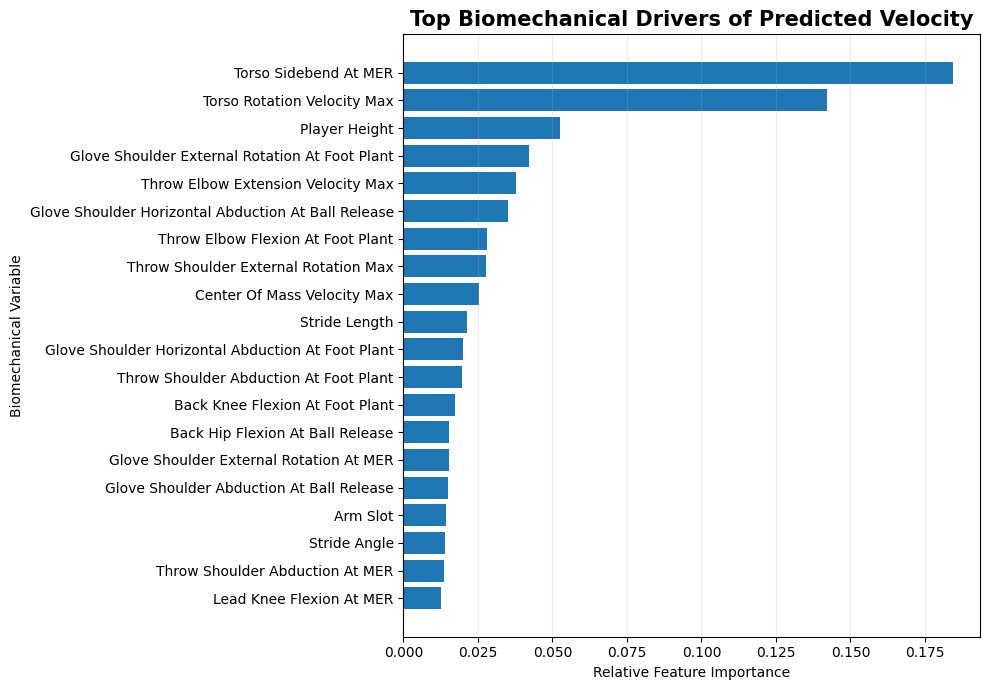

In [ ]:
# ============================================================
# Feature Importance: Model Drivers of Predicted Velocity
# ============================================================

# ------------------------------------------------------------
# Extract feature importance from the best validation model
# ------------------------------------------------------------

if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({
        "feature": X_train_model.columns,
        "importance": best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        "importance",
        ascending=False
    )

    print("Top 20 Model Feature Importances")
    display(feature_importance.head(20))

    # --------------------------------------------------------
    # Cleaner feature labels for plotting
    # --------------------------------------------------------

    def clean_feature_name(name):
        return (
            name
            .replace("_", " ")
            .replace("velo", "velocity")
            .replace("mer", "MER")
            .replace("fcl", "FCL")
            .title()
            .replace("Mer", "MER")
        )

    top_features = feature_importance.head(20).copy()
    top_features["clean_feature"] = top_features["feature"].apply(clean_feature_name)
    top_features = top_features.sort_values("importance")

    # --------------------------------------------------------
    # Plot top model drivers
    # --------------------------------------------------------

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["clean_feature"],
        top_features["importance"]
    )

    plt.title("Top Biomechanical Drivers of Predicted Velocity", fontsize=15, fontweight="bold")
    plt.xlabel("Relative Feature Importance")
    plt.ylabel("Biomechanical Variable")
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

else:
    print("The selected model does not provide feature_importances_.")

In [ ]:
# ============================================================
# Train Final Model and Predict 2025 FCL Pitch Velocities
# ============================================================

# ------------------------------------------------------------
# Re-create the best model type using the same parameters
# ------------------------------------------------------------

final_model = best_model.__class__(**best_model.get_params())

# ------------------------------------------------------------
# Train final model on the full training dataset
# ------------------------------------------------------------

final_model.fit(X_train_model, y)

# ------------------------------------------------------------
# Generate pitch-level velocity predictions for 2025 FCL pitchers
# ------------------------------------------------------------

fcl_raw_predictions = final_model.predict(X_fcl_model)

# ------------------------------------------------------------
# Apply validation bias correction
# ------------------------------------------------------------
# In validation, the model slightly overpredicted on average.
# This correction shifts FCL predictions by the observed mean error.

mean_validation_error = validation_results["prediction_error"].mean()

fcl_calibrated_predictions = fcl_raw_predictions - mean_validation_error

# ------------------------------------------------------------
# Store predictions with original FCL identifiers
# ------------------------------------------------------------

fcl_predictions = df_fcl.copy()

fcl_predictions["raw_predicted_velocity"] = fcl_raw_predictions
fcl_predictions["calibrated_predicted_velocity"] = fcl_calibrated_predictions

# ------------------------------------------------------------
# Display pitch-level prediction preview
# ------------------------------------------------------------

print("Pitch-Level FCL Prediction Preview")

display(
    fcl_predictions[
        [
            "pitcher_id",
            "pitcher_handedness",
            "player_height",
            "raw_predicted_velocity",
            "calibrated_predicted_velocity"
        ]
    ].head(10)
)

# ------------------------------------------------------------
# Display pitch-level prediction summary
# ------------------------------------------------------------

print("FCL Pitch-Level Prediction Summary")

display(
    fcl_predictions[
        ["raw_predicted_velocity", "calibrated_predicted_velocity"]
    ].describe()
)

Pitch-Level FCL Prediction Preview


,pitcher_id,pitcher_handedness,player_height,raw_predicted_velocity,calibrated_predicted_velocity
0,235,l,6.14,90.601842,90.679612
1,64,r,5.86,92.983982,93.061752
2,266,r,6.19,92.259679,92.337449
3,267,r,5.81,92.200837,92.278607
4,262,r,6.14,92.606332,92.684101
5,161,l,6.02,92.212385,92.290155
6,108,r,5.94,90.425830,90.503600
7,274,l,6.35,92.914692,92.992461
8,187,r,5.92,91.974287,92.052056
9,262,r,5.91,93.089844,93.167614


FCL Pitch-Level Prediction Summary


,raw_predicted_velocity,calibrated_predicted_velocity
count,5450.000000,5450.000000
mean,92.431402,92.509172
std,1.205219,1.205219
min,86.224020,86.301790
25%,91.868640,91.946410
50%,92.652998,92.730768
75%,93.172775,93.250545
max,97.136037,97.213807


In [ ]:
# ============================================================
# Aggregate FCL Predictions to the Pitcher Level
# ============================================================

# ------------------------------------------------------------
# Create pitcher-level projection summary
# ------------------------------------------------------------

fcl_pitcher_projection = (
    fcl_predictions
    .groupby("pitcher_id")
    .agg(
        pitch_count=("calibrated_predicted_velocity", "count"),
        handedness=("pitcher_handedness", "first"),
        player_height=("player_height", "mean"),
        mean_projected_velocity=("calibrated_predicted_velocity", "mean"),
        median_projected_velocity=("calibrated_predicted_velocity", "median"),
        p90_projected_velocity=("calibrated_predicted_velocity", lambda x: x.quantile(0.90)),
        p95_projected_velocity=("calibrated_predicted_velocity", lambda x: x.quantile(0.95)),
        max_projected_velocity=("calibrated_predicted_velocity", "max")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Add sample reliability label
# ------------------------------------------------------------

def assign_sample_reliability(pitch_count):
    if pitch_count < 20:
        return "Low sample"
    elif pitch_count < 100:
        return "Moderate sample"
    else:
        return "Strong sample"

fcl_pitcher_projection["sample_reliability"] = (
    fcl_pitcher_projection["pitch_count"].apply(assign_sample_reliability)
)

# ------------------------------------------------------------
# Sort by pitcher-level projected velocity
# ------------------------------------------------------------

fcl_pitcher_projection = fcl_pitcher_projection.sort_values(
    by=["mean_projected_velocity", "p90_projected_velocity"],
    ascending=False
)

# ------------------------------------------------------------
# Display top projected pitchers
# ------------------------------------------------------------

print("Top 15 FCL Pitchers by Mean Projected Velocity")
display(fcl_pitcher_projection.head(15))

Top 15 FCL Pitchers by Mean Projected Velocity


,pitcher_id,pitch_count,handedness,player_height,mean_projected_velocity,median_projected_velocity,p90_projected_velocity,p95_projected_velocity,max_projected_velocity,sample_reliability
2,16,15,r,6.386667,94.586008,94.671823,95.067055,95.137122,95.155001,Low sample
22,119,212,r,6.094245,93.954296,93.966583,94.419605,94.559672,95.060754,Strong sample
65,265,63,r,6.111429,93.559643,93.265913,95.536331,95.659303,95.786884,Moderate sample
37,171,95,r,6.094105,93.432984,93.688958,94.577445,94.653537,94.849077,Moderate sample
48,212,47,r,6.493404,93.309553,93.239433,93.811266,93.960745,96.635238,Moderate sample
24,126,10,l,6.028000,93.274721,93.375945,93.521717,93.567949,93.614181,Low sample
13,96,234,r,5.886795,93.259944,93.221580,93.868784,94.039318,94.457147,Strong sample
12,94,159,l,6.304403,93.211605,93.239951,94.285108,94.348243,94.672879,Strong sample
10,81,270,r,6.099296,93.195614,93.275891,94.281720,94.686159,95.443362,Strong sample
11,91,67,l,5.813582,93.179169,93.176122,93.392296,93.454991,93.763883,Moderate sample


## Velocity Development Across Levels

Predicting current velocity is only part of the question. The prompt is asking about five years from now, so I also wanted to think about how velocity might develop over time.

The best development clue in this dataset comes from pitchers who appear in both the 2024 FCL data and the 2025 FSL data. Those pitchers give a small look at how velocity changed as they moved up a level.

This is not a perfect aging curve because the dataset does not include birthdates. So I cannot say one pitcher is younger, older, or has more physical projection than another. Because of that, I treated the observed level-up velocity change as a general development reference instead of giving every pitcher a different aging adjustment.

In [ ]:
# ============================================================
# Development Signal: How Velo Moves Climbing a Level
# ============================================================

if "year" not in df_train.columns:
    df_train["year"] = pd.to_datetime(df_train["date"], errors="coerce").dt.year

repeat_ids = sorted(
    set(df_train.loc[df_train["year"] == 2024, "pitcher_id"]) &
    set(df_train.loc[df_train["year"] == 2025, "pitcher_id"])
)

repeat = (
    df_train[df_train["pitcher_id"].isin(repeat_ids)]
    .groupby(["pitcher_id", "year"])["velocity"]
    .mean()
    .unstack()
)

repeat["velo_change"] = repeat[2025] - repeat[2024]
level_gain_median = repeat["velo_change"].median()

print(f"{len(repeat)} pitchers threw in both 2024 FCL and 2025 FSL.")
print(
    f"Velo change climbing one level: mean {repeat['velo_change'].mean():+.2f}, "
    f"median {level_gain_median:+.2f}, sd {repeat['velo_change'].std():.2f} mph"
)

display(repeat.round(2))

print("Top-5 under different shared development premiums (sanity check):")

for premium in [0.0, level_gain_median, 1.5]:
    top5 = (
        fcl_pitcher_projection
        .assign(projected=lambda d: d["mean_projected_velocity"] + premium)
        .sort_values("projected", ascending=False)
        .head(5)["pitcher_id"]
        .tolist()
    )

    print(f"  +{premium:.2f} mph: {top5}")

# ------------------------------------------------------------
# Within-FCL trend:
# pitchers with 2024 AND 2025 mechanics in the unfiltered file
# ------------------------------------------------------------

fcl_all_X = (
    pd.get_dummies(df_fcl_all[feature_columns])
    .reindex(columns=X_train_model.columns, fill_value=0)
    .fillna(training_medians)
)

df_fcl_all = df_fcl_all.copy()
df_fcl_all["model_pred"] = final_model.predict(fcl_all_X)
df_fcl_all["yr"] = df_fcl_all["date"].dt.year

fcl_trend = (
    df_fcl_all[df_fcl_all["yr"].isin([2024, 2025])]
    .pivot_table(index="pitcher_id", columns="yr", values="model_pred")
    .dropna()
)

fcl_trend["pred_trend"] = fcl_trend[2025] - fcl_trend[2024]

fcl_pitcher_projection = fcl_pitcher_projection.merge(
    fcl_trend["pred_trend"],
    on="pitcher_id",
    how="left"
)

print(
    f"\n{len(fcl_trend)} FCL pitchers have two years of mechanics. "
    f"Predicted-velo trend (2025 minus 2024), sorted:"
)

display(fcl_trend["pred_trend"].sort_values(ascending=False).round(2).to_frame())

10 pitchers threw in both 2024 FCL and 2025 FSL.
Velo change climbing one level: mean +0.62, median +1.10, sd 1.89 mph


year,2024,2025,velo_change
pitcher_id,,,
25,95.17,98.17,3.00
41,94.89,93.90,-0.99
52,89.93,87.64,-2.29
53,90.57,91.48,0.91
73,93.97,95.25,1.28
103,92.83,95.05,2.22
128,90.62,92.21,1.59
141,93.23,91.29,-1.94
183,88.99,91.63,2.64


Top-5 under different shared development premiums (sanity check):
  +0.00 mph: [16, 119, 265, 171, 212]
  +1.10 mph: [16, 119, 265, 171, 212]
  +1.50 mph: [16, 119, 265, 171, 212]

16 FCL pitchers have two years of mechanics. Predicted-velo trend (2025 minus 2024), sorted:


,pred_trend
pitcher_id,
96,1.12
119,0.77
133,0.54
121,0.54
81,0.50
132,0.36
110,0.31
106,0.31
222,0.23


## How Robust Is the Ranking?

The model is useful, but it is not perfect. The error is big enough that I do not want to overreact to tiny differences between pitchers.

To check how stable the rankings were, I used a bootstrap approach. Basically, I resampled pitches, refit the model, and ranked the pitchers again many times. This shows which pitchers keep showing up near the top and which ones only look good in one version of the data.

This is especially important for small-sample pitchers. A guy with 10 or 15 fastballs can look really strong just because of a few pitches. The bootstrap helps separate the names that are consistently near the top from the ones that are more random.

In [ ]:
# ============================================================
# Bootstrap: Ranking Stability
# ============================================================

rng = np.random.default_rng(7)

# 25 is enough for this notebook and keeps Colab from taking forever
N_BOOTSTRAP = 25

X_tr = X_train_model.values
y_tr = y.values
pid_tr = df_train["pitcher_id"].values

X_fc = X_fcl_model.values
pid_fc = df_fcl["pitcher_id"].values

train_pos = {
    pid: np.where(pid_tr == pid)[0]
    for pid in np.unique(pid_tr)
}

fcl_pos = {
    pid: np.where(pid_fc == pid)[0]
    for pid in np.unique(pid_fc)
}

fcl_ids = list(fcl_pos.keys())

samples = {pid: [] for pid in fcl_ids}
top5_count = {pid: 0 for pid in fcl_ids}

boot_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=5,
    random_state=0,
    n_jobs=-1
)

for b in range(N_BOOTSTRAP):

    print(f"Bootstrap run {b + 1}/{N_BOOTSTRAP}")

    # Resample training pitches within each pitcher
    tr_idx = np.concatenate([
        rng.choice(pos, len(pos), replace=True)
        for pos in train_pos.values()
    ])

    boot_model.fit(X_tr[tr_idx], y_tr[tr_idx])

    # Resample FCL pitches within each pitcher
    fc_idx = []
    fc_lab = []

    for pid, pos in fcl_pos.items():
        s = rng.choice(pos, len(pos), replace=True)
        fc_idx.append(s)
        fc_lab.append(np.full(len(s), pid))

    fc_idx = np.concatenate(fc_idx)
    fc_lab = np.concatenate(fc_lab)

    preds = pd.Series(
        boot_model.predict(X_fc[fc_idx])
    ).groupby(fc_lab).mean()

    for pid in fcl_ids:
        samples[pid].append(preds[pid])

    for pid in preds.nlargest(5).index:
        top5_count[pid] += 1

# ------------------------------------------------------------
# Build bootstrap summary table
# ------------------------------------------------------------

bootstrap_summary = pd.DataFrame({
    "pitcher_id": fcl_ids,
    "boot_lo": [np.percentile(samples[p], 10) for p in fcl_ids],
    "boot_hi": [np.percentile(samples[p], 90) for p in fcl_ids],
    "top5_pct": [100 * top5_count[p] / N_BOOTSTRAP for p in fcl_ids],
})

# ------------------------------------------------------------
# Clean old bootstrap columns before merging
# This prevents boot_lo_x / boot_lo_y duplicate-column issues.
# ------------------------------------------------------------

old_boot_cols = [
    col for col in fcl_pitcher_projection.columns
    if col.startswith("boot_lo")
    or col.startswith("boot_hi")
    or col.startswith("top5_pct")
]

if len(old_boot_cols) > 0:
    fcl_pitcher_projection = fcl_pitcher_projection.drop(columns=old_boot_cols)

# ------------------------------------------------------------
# Merge bootstrap results into pitcher projection table
# ------------------------------------------------------------

fcl_pitcher_projection = fcl_pitcher_projection.merge(
    bootstrap_summary,
    on="pitcher_id",
    how="left"
)

# ------------------------------------------------------------
# Qualified ranking
# ------------------------------------------------------------

qualified = (
    fcl_pitcher_projection[fcl_pitcher_projection["pitch_count"] >= 20]
    .sort_values("mean_projected_velocity", ascending=False)
    .reset_index(drop=True)
)

print("Qualified ranking (>= 20 fastballs): top 8 with bootstrap stability")

display_cols = [
    "pitcher_id",
    "handedness",
    "player_height",
    "pitch_count",
    "mean_projected_velocity",
    "boot_lo",
    "boot_hi",
    "top5_pct",
    "pred_trend"
]

# Only show columns that exist, so the cell does not crash
display_cols = [col for col in display_cols if col in qualified.columns]

display(
    qualified[display_cols]
    .head(8)
    .round(2)
)

Bootstrap run 1/25
Bootstrap run 2/25
Bootstrap run 3/25
Bootstrap run 4/25
Bootstrap run 5/25
Bootstrap run 6/25
Bootstrap run 7/25
Bootstrap run 8/25
Bootstrap run 9/25
Bootstrap run 10/25
Bootstrap run 11/25
Bootstrap run 12/25
Bootstrap run 13/25
Bootstrap run 14/25
Bootstrap run 15/25
Bootstrap run 16/25
Bootstrap run 17/25
Bootstrap run 18/25
Bootstrap run 19/25
Bootstrap run 20/25
Bootstrap run 21/25
Bootstrap run 22/25
Bootstrap run 23/25
Bootstrap run 24/25
Bootstrap run 25/25
Qualified ranking (>= 20 fastballs): top 8 with bootstrap stability


,pitcher_id,handedness,player_height,pitch_count,mean_projected_velocity,boot_lo,boot_hi,top5_pct,pred_trend
0,119,r,6.09,212,93.95,94.06,94.32,100.0,0.77
1,265,r,6.11,63,93.56,93.14,93.79,76.0,NaN
2,171,r,6.09,95,93.43,92.76,93.18,12.0,NaN
3,212,r,6.49,47,93.31,92.72,93.40,16.0,NaN
4,96,r,5.89,234,93.26,93.06,93.56,52.0,1.12
5,94,l,6.30,159,93.21,92.79,93.33,20.0,NaN
6,81,r,6.10,270,93.20,92.85,93.23,4.0,0.50
7,91,l,5.81,67,93.18,92.55,93.18,8.0,NaN


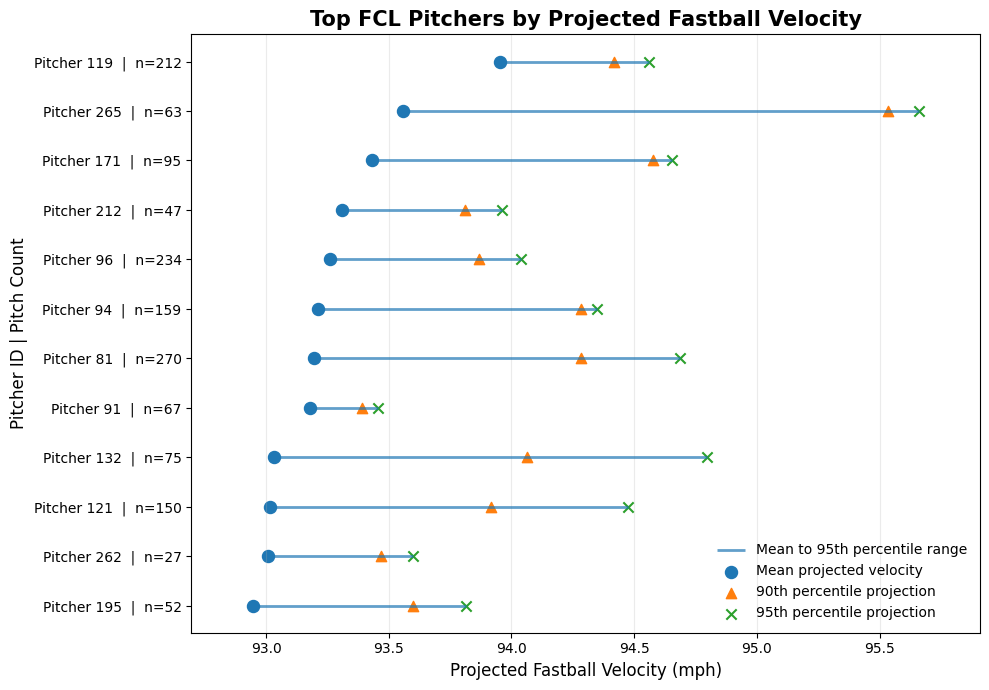

,pitcher_id,handedness,player_height,pitch_count,sample_reliability,mean_projected_velocity,p90_projected_velocity,p95_projected_velocity,max_projected_velocity
0,119,r,6.09,212,Strong sample,93.95,94.42,94.56,95.06
1,265,r,6.11,63,Moderate sample,93.56,95.54,95.66,95.79
2,171,r,6.09,95,Moderate sample,93.43,94.58,94.65,94.85
3,212,r,6.49,47,Moderate sample,93.31,93.81,93.96,96.64
4,96,r,5.89,234,Strong sample,93.26,93.87,94.04,94.46
5,94,l,6.30,159,Strong sample,93.21,94.29,94.35,94.67
6,81,r,6.10,270,Strong sample,93.20,94.28,94.69,95.44
7,91,l,5.81,67,Moderate sample,93.18,93.39,93.45,93.76
8,132,r,6.19,75,Moderate sample,93.03,94.06,94.80,95.86
9,121,r,5.90,150,Strong sample,93.02,93.92,94.47,94.55


In [ ]:
# ============================================================
# Clean Visualization: Top FCL Pitcher Projections
# ============================================================

# ------------------------------------------------------------
# Select top projected pitchers
# ------------------------------------------------------------

top_fcl_pitchers = qualified.head(12).copy()

# Sort for horizontal plotting
plot_df = top_fcl_pitchers.sort_values("mean_projected_velocity", ascending=True).copy()

# Create cleaner display labels
plot_df["pitcher_label"] = (
    "Pitcher " + plot_df["pitcher_id"].astype(str) +
    "  |  n=" + plot_df["pitch_count"].astype(str)
)

# ------------------------------------------------------------
# Create zoomed-in projection plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

y_positions = np.arange(len(plot_df))

# Line from mean projection to 95th percentile projection
plt.hlines(
    y=y_positions,
    xmin=plot_df["mean_projected_velocity"],
    xmax=plot_df["p95_projected_velocity"],
    linewidth=2,
    alpha=0.7,
    label="Mean to 95th percentile range"
)

# Mean projected velocity
plt.scatter(
    plot_df["mean_projected_velocity"],
    y_positions,
    s=75,
    label="Mean projected velocity"
)

# 90th percentile projection
plt.scatter(
    plot_df["p90_projected_velocity"],
    y_positions,
    s=55,
    marker="^",
    label="90th percentile projection"
)

# 95th percentile projection
plt.scatter(
    plot_df["p95_projected_velocity"],
    y_positions,
    s=55,
    marker="x",
    label="95th percentile projection"
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.yticks(y_positions, plot_df["pitcher_label"])

x_min = plot_df["mean_projected_velocity"].min() - 0.25
x_max = plot_df["p95_projected_velocity"].max() + 0.25

plt.xlim(x_min, x_max)

plt.title("Top FCL Pitchers by Projected Fastball Velocity", fontsize=15, fontweight="bold")
plt.xlabel("Projected Fastball Velocity (mph)", fontsize=12)
plt.ylabel("Pitcher ID | Pitch Count", fontsize=12)

plt.grid(axis="x", alpha=0.25)
plt.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Cleaner top candidate table
# ------------------------------------------------------------

top_candidate_table = top_fcl_pitchers[
    [
        "pitcher_id",
        "handedness",
        "player_height",
        "pitch_count",
        "sample_reliability",
        "mean_projected_velocity",
        "p90_projected_velocity",
        "p95_projected_velocity",
        "max_projected_velocity"
    ]
].copy()

# Round for cleaner display
rounded_cols = [
    "player_height",
    "mean_projected_velocity",
    "p90_projected_velocity",
    "p95_projected_velocity",
    "max_projected_velocity"
]

top_candidate_table[rounded_cols] = top_candidate_table[rounded_cols].round(2)

display(top_candidate_table)

In [ ]:
# ============================================================
# Biomechanical Profile of Top Projected FCL Pitchers
# ============================================================

# ------------------------------------------------------------
# Define key biomechanical variables from model importance
# Do NOT include player_height here because it already exists
# in fcl_pitcher_projection.
# ------------------------------------------------------------

key_biomech_features = [
    "torso_sidebend_at_mer",
    "torso_rotation_velo_max",
    "torso_sidebend_at_ball_release",
    "throw_elbow_extension_velo_max",
    "center_of_mass_velo_max",
    "arm_slot"
]

# Keep only features that exist in the FCL dataset
key_biomech_features = [
    feature for feature in key_biomech_features
    if feature in df_fcl.columns
]

# ------------------------------------------------------------
# Create FCL pitcher-level biomechanical averages
# ------------------------------------------------------------

fcl_biomech_profile = (
    df_fcl
    .groupby("pitcher_id")[key_biomech_features]
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# Merge biomechanical profiles with pitcher projections
# ------------------------------------------------------------

top_pitcher_profiles = (
    fcl_pitcher_projection
    .merge(fcl_biomech_profile, on="pitcher_id", how="left")
    .sort_values("mean_projected_velocity", ascending=False)
)

# ------------------------------------------------------------
# Display top candidates with biomechanical context
# ------------------------------------------------------------

profile_columns = [
    "pitcher_id",
    "handedness",
    "pitch_count",
    "sample_reliability",
    "player_height",
    "mean_projected_velocity",
    "p90_projected_velocity",
    "p95_projected_velocity"
] + key_biomech_features

top_profile_table = (
    top_pitcher_profiles[top_pitcher_profiles["pitch_count"] >= 20][profile_columns]
    .head(10)
    .copy()
)

# Round numeric columns for readability
numeric_cols = top_profile_table.select_dtypes(include=[np.number]).columns
top_profile_table[numeric_cols] = top_profile_table[numeric_cols].round(2)

print("Top Projected Pitchers with Biomechanical Profile")
display(top_profile_table)

Top Projected Pitchers with Biomechanical Profile


,pitcher_id,handedness,pitch_count,sample_reliability,player_height,mean_projected_velocity,p90_projected_velocity,p95_projected_velocity,torso_sidebend_at_mer,torso_rotation_velo_max,torso_sidebend_at_ball_release,throw_elbow_extension_velo_max,center_of_mass_velo_max,arm_slot
1,119,r,212,Strong sample,6.09,93.95,94.42,94.56,45.82,1265.19,45.49,2246.60,10.30,46.34
2,265,r,63,Moderate sample,6.11,93.56,95.54,95.66,22.89,1102.85,22.41,2100.84,9.88,43.01
3,171,r,95,Moderate sample,6.09,93.43,94.58,94.65,23.42,1353.67,24.35,1820.49,10.53,26.30
4,212,r,47,Moderate sample,6.49,93.31,93.81,93.96,16.50,1131.58,10.50,1456.98,8.23,12.09
6,96,r,234,Strong sample,5.89,93.26,93.87,94.04,19.87,1134.32,19.69,2173.99,8.78,19.94
7,94,l,159,Strong sample,6.30,93.21,94.29,94.35,19.84,876.80,18.74,1771.41,11.10,22.71
8,81,r,270,Strong sample,6.10,93.20,94.28,94.69,27.30,1064.72,27.03,1822.50,10.01,24.71
9,91,l,67,Moderate sample,5.81,93.18,93.39,93.45,34.90,1166.05,35.84,2261.12,8.09,48.91
10,132,r,75,Moderate sample,6.19,93.03,94.06,94.80,36.03,2232.93,28.84,2110.53,10.71,19.51
11,121,r,150,Strong sample,5.90,93.02,93.92,94.47,27.36,1296.97,26.82,2149.03,8.16,24.22


In [ ]:
# ============================================================
# Percentile Context for Top FCL Candidates
# ============================================================

percentile_features = [
    "mean_projected_velocity",
    "p90_projected_velocity",
    "p95_projected_velocity",
    "pitch_count",
    "player_height",
    "torso_sidebend_at_mer",
    "torso_rotation_velo_max",
    "torso_sidebend_at_ball_release",
    "throw_elbow_extension_velo_max",
    "center_of_mass_velo_max",
    "arm_slot"
]

percentile_features = [
    c for c in percentile_features
    if c in top_pitcher_profiles.columns
]

# Percentiles are relative to the full FCL group
fcl_percentile_profiles = top_pitcher_profiles.copy()

for col in percentile_features:
    fcl_percentile_profiles[col + "_percentile"] = (
        fcl_percentile_profiles[col].rank(pct=True) * 100
    )

# Display columns now include bootstrap stability and the development trend
context_display_cols = [
    "pitcher_id",
    "handedness",
    "pitch_count",
    "sample_reliability",
    "player_height",
    "mean_projected_velocity",
    "top5_pct",
    "boot_lo",
    "boot_hi",
    "pred_trend",
    "mean_projected_velocity_percentile",
    "torso_sidebend_at_mer_percentile",
    "torso_rotation_velo_max_percentile",
    "throw_elbow_extension_velo_max_percentile"
]

context_display_cols = [
    c for c in context_display_cols
    if c in fcl_percentile_profiles.columns
]

# Gate to pitchers with a usable sample before ranking
candidate_context_table = (
    fcl_percentile_profiles[fcl_percentile_profiles["pitch_count"] >= 20]
    .sort_values("mean_projected_velocity", ascending=False)[context_display_cols]
    .head(15)
    .reset_index(drop=True)
    .copy()
)

candidate_context_table.insert(0, "rank", candidate_context_table.index + 1)

numeric_cols = candidate_context_table.select_dtypes(include=[np.number]).columns
candidate_context_table[numeric_cols] = candidate_context_table[numeric_cols].round(2)

print("Qualified FCL candidates by model-projected velocity, with stability and biomechanical context")
display(candidate_context_table)

Qualified FCL candidates by model-projected velocity, with stability and biomechanical context


,rank,pitcher_id,handedness,pitch_count,sample_reliability,player_height,mean_projected_velocity,top5_pct,boot_lo,boot_hi,pred_trend,mean_projected_velocity_percentile,torso_sidebend_at_mer_percentile,torso_rotation_velo_max_percentile,throw_elbow_extension_velo_max_percentile
0,1,119,r,212,Strong sample,6.09,93.95,100.0,94.06,94.32,0.77,98.59,100.00,90.14,92.96
1,2,265,r,63,Moderate sample,6.11,93.56,76.0,93.14,93.79,NaN,97.18,54.93,63.38,80.28
2,3,171,r,95,Moderate sample,6.09,93.43,12.0,92.76,93.18,NaN,95.77,57.75,94.37,32.39
3,4,212,r,47,Moderate sample,6.49,93.31,16.0,92.72,93.40,NaN,94.37,15.49,67.61,5.63
4,5,96,r,234,Strong sample,5.89,93.26,52.0,93.06,93.56,1.12,91.55,43.66,70.42,88.73
5,6,94,l,159,Strong sample,6.30,93.21,20.0,92.79,93.33,NaN,90.14,40.85,5.63,28.17
6,7,81,r,270,Strong sample,6.10,93.20,4.0,92.85,93.23,0.50,88.73,80.28,52.11,35.21
7,8,91,l,67,Moderate sample,5.81,93.18,8.0,92.55,93.18,NaN,87.32,94.37,77.46,94.37
8,9,132,r,75,Moderate sample,6.19,93.03,8.0,92.50,93.27,0.36,85.92,95.77,100.00,81.69
9,10,121,r,150,Strong sample,5.90,93.02,0.0,92.68,92.96,0.54,84.51,83.10,92.96,84.51


In [ ]:
# ============================================================
# Final Candidate Profile and Export
# ============================================================

# ------------------------------------------------------------
# Identify top candidate from mean model-projected velocity
# ------------------------------------------------------------
# The final candidate is selected from the primary model projection ranking.
# Reliability and biomechanical percentiles are used as context rather than
# being combined into an arbitrary weighted score.

final_candidate_id = int(qualified.iloc[0]["pitcher_id"])

print(f"Final leading candidate: Pitcher {final_candidate_id}")

# ------------------------------------------------------------
# Display top candidates for comparison
# ------------------------------------------------------------

top_5_candidates = candidate_context_table.head(5).copy()

print("Top Candidate Comparison")
display(top_5_candidates)

# ------------------------------------------------------------
# Pull detailed profile for the leading candidate
# ------------------------------------------------------------

final_candidate_profile = (
    fcl_percentile_profiles[
        fcl_percentile_profiles["pitcher_id"] == final_candidate_id
    ]
    .copy()
)

# ------------------------------------------------------------
# Select key final profile columns
# ------------------------------------------------------------

final_candidate_columns = [
    "pitcher_id",
    "handedness",
    "pitch_count",
    "sample_reliability",
    "player_height",
    "mean_projected_velocity",
    "p90_projected_velocity",
    "p95_projected_velocity",
    "max_projected_velocity",
    "mean_projected_velocity_percentile",
    "p95_projected_velocity_percentile",
    "pitch_count_percentile",
    "player_height_percentile",
    "torso_sidebend_at_mer_percentile",
    "torso_rotation_velo_max_percentile",
    "throw_elbow_extension_velo_max_percentile"
]

final_candidate_columns = [
    col for col in final_candidate_columns
    if col in final_candidate_profile.columns
]

final_candidate_profile = final_candidate_profile[final_candidate_columns]

# Round numeric values for clean display
numeric_cols = final_candidate_profile.select_dtypes(include=[float, int]).columns
final_candidate_profile[numeric_cols] = final_candidate_profile[numeric_cols].round(2)

# ------------------------------------------------------------
# Create clean transposed display table
# ------------------------------------------------------------

final_candidate_display = final_candidate_profile.T.copy()
final_candidate_display.columns = [f"Pitcher {final_candidate_id}"]

print("Final Candidate Detailed Profile")
display(final_candidate_display)

# ------------------------------------------------------------
# Export with clean filenames
# ------------------------------------------------------------

ranking_filename = "top_fcl_projection_candidates_FINAL.csv"
profile_filename = f"final_candidate_pitcher_{final_candidate_id}_profile_FINAL.csv"

candidate_context_table.to_csv(ranking_filename, index=False)
final_candidate_display.to_csv(profile_filename)

print("Exported final tables:")
print(f"- {ranking_filename}")
print(f"- {profile_filename}")

Final leading candidate: Pitcher 119
Top Candidate Comparison


,rank,pitcher_id,handedness,pitch_count,sample_reliability,player_height,mean_projected_velocity,top5_pct,boot_lo,boot_hi,pred_trend,mean_projected_velocity_percentile,torso_sidebend_at_mer_percentile,torso_rotation_velo_max_percentile,throw_elbow_extension_velo_max_percentile
0,1,119,r,212,Strong sample,6.09,93.95,100.0,94.06,94.32,0.77,98.59,100.00,90.14,92.96
1,2,265,r,63,Moderate sample,6.11,93.56,76.0,93.14,93.79,NaN,97.18,54.93,63.38,80.28
2,3,171,r,95,Moderate sample,6.09,93.43,12.0,92.76,93.18,NaN,95.77,57.75,94.37,32.39
3,4,212,r,47,Moderate sample,6.49,93.31,16.0,92.72,93.40,NaN,94.37,15.49,67.61,5.63
4,5,96,r,234,Strong sample,5.89,93.26,52.0,93.06,93.56,1.12,91.55,43.66,70.42,88.73


Final Candidate Detailed Profile


,Pitcher 119
pitcher_id,119
handedness,r
pitch_count,212
sample_reliability,Strong sample
player_height,6.09
mean_projected_velocity,93.95
p90_projected_velocity,94.42
p95_projected_velocity,94.56
max_projected_velocity,95.06
mean_projected_velocity_percentile,98.59


Exported final tables:
- top_fcl_projection_candidates_FINAL.csv
- final_candidate_pitcher_119_profile_FINAL.csv


## Final Recommendation

**The pitcher I identified as the most likely to throw the hardest fastball five years from now was Pitcher 119.**

He is the strongest answer because he checks the most important boxes at the same time. He has the best qualified projected velocity, a strong pitch sample, and he holds up well when I test the ranking with the bootstrap.

One important detail is that Pitcher 16 actually shows up very high in the raw results, but he only has 15 fastballs. That is too small of a sample to trust as the main answer. It could be real, but it could also just be a small-sample spike. Once I use the 20-pitch minimum reliability filter, Pitcher 119 becomes the clear top choice.

Pitcher 119 projects around 94 mph on average and has 212 fastballs in the 2025 sample. That makes his projection much more stable than most of the other pitchers. His biomechanical profile also makes sense with the model. He scores well in areas connected to velocity, especially trunk positioning, trunk rotation speed, and throwing-arm speed.

The group behind him is much closer. Pitchers like 265, 96, 94, 171, and 195 all sit in a similar low-93 mph range. I would treat them more like a tier than a strict ranking because the differences between them are smaller than the model error. Pitcher 94 is interesting too because he is a 6'4" lefty, and that kind of physical profile could matter over a five-year window, even though the model cannot fully capture projection without age or more body data.

For the five-year part, I used the pitchers who moved from 2024 FCL to 2025 FSL as a rough development reference. That group gained about a mile per hour on average or by median, depending on how it is summarized. Since there are no birthdates, I did not want to pretend I could build a perfect aging curve. I used that level-up gain more as context than as something that changes the whole ranking.

Overall, the honest answer is that the model gives a confident top pick, but not a perfect future prediction. The biomechanics explain some of velocity, but definitely not all of it. Within those limits, **Pitcher 119 is the most defensible pick to throw the hardest fastball five years from now among the 2025 FCL pitchers.**

### Reference

Aguinaldo, A. L., & Escamilla, R. F. (2019). *Segmental Power Analysis of Sequential Body Motion and Elbow Valgus Loading During Baseball Pitching: Comparison Between Professional and High School Baseball Players*. American Journal of Sports Medicine, 47(7), 1600–1608.

This paper reflects biomechanical concepts that were emphasized during my graduate coursework at Point Loma Nazarene University and helped shape how I thought about evaluating pitching mechanics in this project. It also reinforced the idea that pitching velocity is produced through coordinated whole-body movement rather than a single mechanical factor.